In [86]:
import sys

In [87]:
sys.executable

'c:\\ProgramData\\anaconda3\\python.exe'

In [88]:
import numpy  as np
import pandas as pd


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from feature_engineering import Feature_Engineering
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OrdinalEncoder
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_curve, precision_recall_curve,average_precision_score,accuracy_score,recall_score,precision_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute    import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [90]:
#file_path = 'churn_preprocessed.csv'
file_path = 'TelecomChurn_POC.csv'

In [91]:
df = pd.read_csv(file_path)
df.head()

,customer_id,age,gender,region,senior_citizen,partner,tenure_months,contract_type,payment_method,internet_service,monthly_charges,total_charges,avg_monthly_calls,data_usage_gb,support_tickets,streaming_tv,tech_support,online_backup,churn
0,CUST665822,56,Male,East,0,0,40,One Year,Bank Transfer,NaN,48.63,1969.30,54,7.05,0,1,0,1,0
1,CUST327221,69,Female,North,1,0,47,Month-to-Month,Electronic Check,DSL,20.00,NaN,45,37.20,1,0,1,0,0
2,CUST805684,46,Other,North,0,1,15,Month-to-Month,Credit Card,Fiber Optic,94.69,1389.05,45,5.78,4,0,1,0,1
3,CUST085472,32,Female,East,0,1,15,Two Year,Electronic Check,Fiber Optic,65.36,956.60,40,3.34,1,1,0,0,0
4,CUST568785,60,Female,East,1,1,72,One Year,Electronic Check,NaN,63.82,4617.34,33,13.56,2,1,0,0,0


In [92]:
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())
df['data_usage_gb'] = df['data_usage_gb'].fillna(df['data_usage_gb'].median())
df['internet_service'] = df['internet_service'].fillna('None')

obj_col = ['gender','region','contract_type','payment_method','internet_service']
df[obj_col] = df[obj_col].astype('category')


In [93]:
#creating variable to store category column for doing onehot encoding and label encoding
ohe_cols = ['gender','region','contract_type','payment_method','internet_service']
le_cols = ['tenure_months_group']
num_cols = ['age','senior_citizen','partner','tenure_months','monthly_charges','total_charges','avg_monthly_calls',
            'data_usage_gb','support_tickets','streaming_tv','tech_support','online_backup','services_count','high_risk_flag']

In [94]:
# creating column transformer pipeline for encoding and normalizing numeralical data
num_pipeline = Pipeline([('scaler', StandardScaler())])
num_pipeline

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [95]:
#creating column transformer pipeline for one hot encoding
nominal_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
nominal_pipeline

,steps,"[('onehot', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [96]:
#creating column transformr pipeline for label encoding
ordinal_pipeline = Pipeline([('ordinal', OrdinalEncoder(categories=[['new','early','mid','loyal']]))])
ordinal_pipeline

,steps,"[('ordinal', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,"[['new', 'early', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [97]:
#combining all column transformer pipeline
preprocessor = Pipeline([
    ("feature_engineering", Feature_Engineering()),  # ✅ added here
    ("column_transform", ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('nominal', nominal_pipeline, ohe_cols),
        ('ordinal', ordinal_pipeline, le_cols)
    ]))
])
preprocessor

,steps,"[('feature_engineering', ...), ('column_transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [98]:
#seperating dependent and independent variable
Target = 'churn'
X = df.drop(columns=[Target])
y = df[Target].values

In [99]:
#splitting the data into 60% training, 20% validation and 20% test data
seed = 12
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,stratify=y_train,random_state=seed)

X_train.shape,y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((3200, 18), (3200,), (800, 18), (800,), (1000, 18), (1000,))

In [100]:

#Applying the processing process
X_train_pp = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_pp   = preprocessor.transform(X_val).astype(np.float32)
X_test_pp  = preprocessor.transform(X_test).astype(np.float32)


In [101]:
X.isna().sum()

customer_id          0
age                  0
gender               0
region               0
senior_citizen       0
partner              0
tenure_months        0
contract_type        0
payment_method       0
internet_service     0
monthly_charges      0
total_charges        0
avg_monthly_calls    0
data_usage_gb        0
support_tickets      0
streaming_tv         0
tech_support         0
online_backup        0
dtype: int64

In [102]:
# applying tensor to preprocessed data
def to_tensor(X_arr,y_arr):

    return (torch.tensor(X_arr,dtype=torch.float32),torch.tensor(y_arr,dtype=torch.float32).unsqueeze(1))  # Target variable shape (n_samples, 1)


In [103]:
X_train_tensor, y_train_tensor = to_tensor(X_train_pp,y_train)
X_val_tensor, y_val_tensor = to_tensor(X_val_pp,y_val)
X_test_tensor, y_test_tensor = to_tensor(X_test_pp,y_test)

In [104]:
X_val_tensor.shape, y_val_tensor.shape

(torch.Size([800, 32]), torch.Size([800, 1]))

In [105]:
# Creating Sample to handle imbalanced data
class_counts  = np.bincount(y_train)                    # [n_neg, n_pos]
class_weights = 1.0 / class_counts                      # inverse frequency
sample_weights = class_weights[y_train]                 # per-sample weight

sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.double),
    num_samples = len(sample_weights),
    replacement = True,
)

In [106]:
#creating dataloaders 

batch_size = 64


train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size = batch_size,
    sampler    = sampler,          # balanced batches
    drop_last  = True,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size = batch_size * 4,  #dont need gradient so larger batch size
    shuffle    = False,
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size = batch_size * 4, #dont need gradient so larger batch size
    shuffle    = False,
)

### Defining Neural Network

In [107]:
class ChurnNN(nn.Module):

    def __init__(self,input_dim, 
                         hidden_dims: tuple = (128, 64, 32), # size of hidden layers, if input dim = 20 then shape will be 20 → 128 → 64 → 32 → 1
                         dropout_rates: tuple = (0.4, 0.3, 0.2)):

        super().__init__()

        assert len(hidden_dims) == len(dropout_rates), "hidden_dims and dropout_rates must be same length."

        layers = []

        in_dim = input_dim


        ''' 
        Model architecture[ Linear(20,128), BN(128),ReLU,Dropout,Linear(128,64),BN(64),ReLU,Dropout,Linear(64,32),BN(32),ReLU,Dropout]

        Three-hidden-layer feedforward network for binary churn prediction.
 
        Architecture
        ─────────────
        Input  →  [128] → BN → ReLU → Dropout(0.4)
               →  [64]  → BN → ReLU → Dropout(0.3)
               →  [32]  →     ReLU → Dropout(0.2)
               →  [1]   (raw logit, no sigmoid — used with BCEWithLogitsLoss)
    
        Design choices
        ──────────────
        • Batch Norm before activation: stabilises training, reduces sensitivity
        to weight initialisation, and acts as a mild regulariser.
        • Decreasing dropout rates (0.4 → 0.3 → 0.2): heavier regularisation
        in wide early layers where overfitting risk is highest.
        • Raw logit output: BCEWithLogitsLoss is numerically more stable than
        BCE(Sigmoid(logit)) because it uses the log-sum-exp trick internally.
        • He (Kaiming) initialisation for ReLU layers (applied in reset_params).
        '''

       # Store layers manually
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()

        self.act = nn.LeakyReLU(negative_slope=0.01)


        in_dim = input_dim
        for h_dim, drop_p in zip(hidden_dims, dropout_rates):
            self.layers.append(nn.Linear(in_dim, h_dim))
            self.batch_norms.append(nn.BatchNorm1d(h_dim))
            self.dropouts.append(nn.Dropout(p=drop_p))
            in_dim = h_dim

        self.output = nn.Linear(in_dim, 1)

        self._init_weights()

    def _init_weights(self):

        '''
        ReLU has a problem: negative values become 0 reduces signal flow

        So Kaiming initialization adjusts weights so that: variance of outputs stays stable across layers
        '''

        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.kaiming_uniform_(m.weight,nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)  #if module is nn.Linear it will have m.weight,m.bias
            
            elif isinstance(m,nn.BatchNorm1d): # BatchNorm1d because tabular data
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    
    def forward(self,x:torch.Tensor) -> torch.Tensor:

        for layer, bn, dropout in zip(self.layers,self.batch_norms,self.dropouts):

            x = layer(x)
            x = bn(x)
            x = self.act(x)
            x = dropout(x)

        x = self.output(x)

        return x


      


        


In [108]:
input_dim = X_train_pp.shape[1]    #has (3200,32) -> has 3200 samples, each sample has 32 shape. SO input will be 32 featurs
input_dim


32

In [109]:
model = ChurnNN(input_dim=input_dim)

In [110]:
model

ChurnNN(
  (layers): ModuleList(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropouts): ModuleList(
    (0): Dropout(p=0.4, inplace=False)
    (1): Dropout(p=0.3, inplace=False)
    (2): Dropout(p=0.2, inplace=False)
  )
  (act): LeakyReLU(negative_slope=0.01)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

In [111]:
#from torchinfo import summary
from torchsummary import summary
summary(model, input_size=(input_dim,))  #batchsize is 64

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           4,224
       BatchNorm1d-2                  [-1, 128]             256
         LeakyReLU-3                  [-1, 128]               0
           Dropout-4                  [-1, 128]               0
            Linear-5                   [-1, 64]           8,256
       BatchNorm1d-6                   [-1, 64]             128
         LeakyReLU-7                   [-1, 64]               0
           Dropout-8                   [-1, 64]               0
            Linear-9                   [-1, 32]           2,080
      BatchNorm1d-10                   [-1, 32]              64
        LeakyReLU-11                   [-1, 32]               0
          Dropout-12                   [-1, 32]               0
           Linear-13                    [-1, 1]              33
Total params: 15,041
Trainable params: 

In [112]:
total_params = sum(p.numel() for p in model.parameters())  #numel(): count no.of element inside parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"{'─'*50}")


  Total parameters     : 15,041
  Trainable parameters : 15,041
──────────────────────────────────────────────────


### Optimizer and Loss Function

In [113]:
# Compute class weights if your dataset is imbalanced
# pos_weight = (# of negative samples) / (# of positive samples)
# Assuming y_train_tensor contains 0 and 1 labels
pos_weight = (y_train_tensor == 0).sum() / (y_train_tensor == 1).sum()
pos_weight = pos_weight.float()


criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
pos_weight,criterion

(tensor(4.5077), BCEWithLogitsLoss())

In [114]:
# defining optimizer
learning_rate = 1e-3

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [115]:
# setting learing rate sceduler. Reduces learning rate by factor gamma every step_size epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [116]:
def train(model, train_loader, criterion, optimizer, device):

    loss = []

    #training mode
    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss


In [117]:
def predict(model, data_loader, device):
    import numpy as np
    import torch

    model.eval()
    y_true, y_probs = [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()

            
            y_probs.extend(probs.flatten())
            y_true.extend(y_batch.numpy().flatten())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    return y_true, y_probs

In [118]:
def find_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.0, 1.0, 101)

    best_threshold = 0.5
    best_f1 = -1

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

In [119]:
def evaluate_model(model, data_loader, device, threshold):
    y_true, y_probs = predict(model, data_loader, device)

    y_pred = (y_probs >= threshold).astype(int)

    metrics = {
        "f1": f1_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_probs),
        "accuracy": accuracy_score(y_true, y_pred),
        "avg_precision": average_precision_score(y_true, y_probs),
        "classification_report": classification_report(y_true, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

    return metrics, y_probs

In [120]:
EPOCHS = 100

history = {
    "train_loss": [],
    "val_f1": []
}

best_score = -1
best_threshold = 0.5

for epoch in range(1, EPOCHS + 1):

    # ---- train ----
    train_loss = train(model, train_loader, criterion, optimizer, device)

    # ---- validation probabilities ----
    y_val_true, y_val_probs = predict(model, val_loader, device)

    # ---- threshold tuning ONLY on validation ----
    epoch_best_threshold, epoch_best_f1 = find_best_threshold(y_val_true, y_val_probs)

    # ---- evaluate using that threshold ----
    val_metrics, val_probs = evaluate_model(model,val_loader,device,threshold=epoch_best_threshold)



    # Logging
    history["train_loss"].append(train_loss)
    history["val_f1"].append(val_metrics["f1"])

    print(
    f"Epoch {epoch}/{EPOCHS} | "
    f"Train Loss: {train_loss:.4f} | "
    f"Val F1: {val_metrics['f1']:.4f} | "
    f"Val AUC: {val_metrics['auc']:.4f} | "
    f"Val Acc: {val_metrics['accuracy']:.4f} | "
    f"Threshold: {epoch_best_threshold:.2f}"
)

    # ---- save best model (based on validation F1) ----
    if val_metrics["f1"] > best_score:
        best_score = val_metrics["f1"]
        best_threshold = epoch_best_threshold

        torch.save({
            "model_state_dict": model.state_dict(),
            "threshold": best_threshold,
            "best_score": best_score
        }, "saved_model.pt")

        print("\n--- Saved Best Model ---")

Epoch 1/100 | Train Loss: 1.6574 | Val F1: 0.3872 | Val AUC: 0.6577 | Val Acc: 0.6162 | Threshold: 0.65

--- Saved Best Model ---
Epoch 2/100 | Train Loss: 1.3519 | Val F1: 0.4272 | Val AUC: 0.7212 | Val Acc: 0.6950 | Threshold: 0.72

--- Saved Best Model ---
Epoch 3/100 | Train Loss: 1.2922 | Val F1: 0.4468 | Val AUC: 0.7513 | Val Acc: 0.6038 | Threshold: 0.70

--- Saved Best Model ---
Epoch 4/100 | Train Loss: 1.2493 | Val F1: 0.4590 | Val AUC: 0.7726 | Val Acc: 0.6288 | Threshold: 0.73

--- Saved Best Model ---
Epoch 5/100 | Train Loss: 1.1907 | Val F1: 0.4678 | Val AUC: 0.7795 | Val Acc: 0.7212 | Threshold: 0.79

--- Saved Best Model ---
Epoch 6/100 | Train Loss: 1.1623 | Val F1: 0.4710 | Val AUC: 0.7780 | Val Acc: 0.6462 | Threshold: 0.73

--- Saved Best Model ---
Epoch 7/100 | Train Loss: 1.1609 | Val F1: 0.4642 | Val AUC: 0.7664 | Val Acc: 0.6538 | Threshold: 0.77
Epoch 8/100 | Train Loss: 1.1221 | Val F1: 0.4697 | Val AUC: 0.7770 | Val Acc: 0.6613 | Threshold: 0.78
Epoch 9/100 

In [121]:
ckpt = torch.load("saved_model.pt", map_location=device, weights_only=False)

model.load_state_dict(ckpt["model_state_dict"])
threshold = ckpt["threshold"]

test_metrics, _ = evaluate_model(
    model,
    test_loader,
    device,
    threshold=threshold
)



# Extract metrics
accuracy = test_metrics['accuracy']
f1_score = test_metrics['f1']
recall = test_metrics['recall']
precision = test_metrics['precision']
auc = test_metrics['auc']

classification_report = test_metrics['classification_report']
confusion_matrix = test_metrics['confusion_matrix']

# Print overall metrics
print(f"Overall Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC: {auc:.4f}")
print()

# Print classification report (per class)
print(f"Classification Report (Per Class):")
for label, metrics in classification_report.items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:  # Skip averages
        print(f"Class {label}:")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1-score']:.4f}")
        print(f"  Support: {metrics['support']}")
        print()

# Print confusion matrix
print(f"Confusion Matrix:")
print(f"True Negatives (Class 0): {confusion_matrix[0][0]}")
print(f"False Positives (Class 0): {confusion_matrix[0][1]}")
print(f"False Negatives (Class 1): {confusion_matrix[1][0]}")
print(f"True Positives (Class 1): {confusion_matrix[1][1]}")

Overall Model Performance:
Accuracy: 0.6350
F1-Score: 0.4393
Recall: 0.7901
Precision: 0.3043
AUC: 0.7540

Classification Report (Per Class):
Class 0.0:
  Precision: 0.9283
  Recall: 0.6007
  F1-Score: 0.7294
  Support: 819.0

Class 1.0:
  Precision: 0.3043
  Recall: 0.7901
  F1-Score: 0.4393
  Support: 181.0

Confusion Matrix:
True Negatives (Class 0): 492
False Positives (Class 0): 327
False Negatives (Class 1): 38
True Positives (Class 1): 143


# Bringing it all together

In [122]:
def churn_predict(input_data, model, preprocessor, device):
    import pandas as pd
    import torch

    # Step 1: dict → DataFrame
    df = pd.DataFrame([input_data])

    # Step 2: Feature Engineering
    #fe = Feature_Engineering()
    #df = fe.transform(df)

    # Step 3: Preprocessing
    df_processed = preprocessor.transform(df)

    # Step 4: Tensor
    x_tensor = torch.tensor(df_processed, dtype=torch.float32).to(device)

    # Step 5: Predict
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        prob = torch.sigmoid(logits).item()

    pred = 1 if prob >= 0.5 else 0

    return {
        "probability": round(prob, 4),
        "prediction": pred
    }

In [123]:
user = {
    'age': 35,
    'gender': 'Male',
    'region': 'North',
    'senior_citizen': 0,
    'partner': 1,
    'tenure_months': 6,
    'contract_type': 'Month-to-month',
    'payment_method': 'Electronic check',
    'internet_service': 'Fiber optic',
    'monthly_charges': 80,
    'total_charges': 500,
    'avg_monthly_calls': 120,
    'data_usage_gb': 15,
    'support_tickets': 3,
    'streaming_tv': 1,
    'tech_support': 0,
    'online_backup': 1
}

In [124]:
churn_predict(user,model,preprocessor,device)

{'probability': 0.6113, 'prediction': 1}

In [125]:
def gradient_importance(model, X_tensor):
    model.eval()

    X_tensor.requires_grad = True
    outputs = model(X_tensor)
    probs = torch.sigmoid(outputs)

    probs.sum().backward()

    grads = X_tensor.grad.detach().cpu().numpy()
    importance = np.mean(np.abs(grads), axis=0)

    return importance

importance = gradient_importance(model, X_train_tensor)



<Axes: >

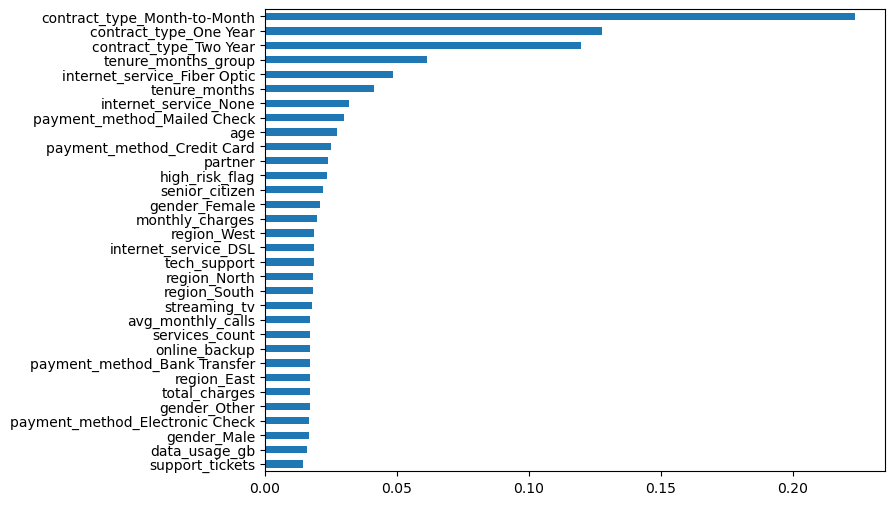

In [126]:
feature_names = preprocessor.named_steps["column_transform"].get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

X_tensor = torch.tensor(X_train_pp, dtype=torch.float32).to(device)

importance = gradient_importance(model, X_tensor)

feature_importance = pd.Series(importance, index=feature_names)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))

### Insights
**Top Drivers of Churn**
1. Contract Type (Dominant Driver): contract_type_Month-to-Month (highest).Month-to-month customers churn the most.Longer contracts reduce churn significantly. As there is no commitment from customer it is easy to leave. Long-term contracts locks the customer, making it difficult to leave.
2. Tenure Month: New Customer churns more while loyal customer churn less.